<a href="https://colab.research.google.com/github/adityachaudhary0/IMDb-Sentiment-Analysis/blob/main/NLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [4]:
df=pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [5]:

df.sample(5)

,review,sentiment
2671,A total and absolute waste of time. Bad acting...,negative
48711,"I`m in two minds about FOLLOWING , the film de...",negative
35079,The quintessential housewife and perfect mothe...,positive
47382,"OK, this movie seems to have been pretty well ...",negative
21201,`Our Song' gives us the lives of the three tee...,positive


In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
df.iloc[11757][0]

/tmp/ipykernel_1017/4260115454.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[11757][0]


'#1 Vampires vs. Humans<br /><br />#2 Military-reject roughneck squad as first responders to dangerous, unknown Vampire incursions.<br /><br />#3 Sexy female Vampire on the side of the "good guys".<br /><br />#4 Plenty of gore and action.<br /><br />There are four (4) major plot devices that may help you decide if you want to watch this movie. If you want all four, then the next plot device may not deter you...<br /><br />#5 In outer space.<br /><br />That last one almost got me too, but I\'m glad I watched. In a pile of terrible direct-to-video horror that is the Sci-Fi channel Halloween marathon... this movie is a breath of fresh air. It will stand-up against any of the other Sci-Fi channel offerings, and even against the other Vampire movie Natassia starred in (who keeps giving Uwe Boll money?).'

<Axes: ylabel='count'>

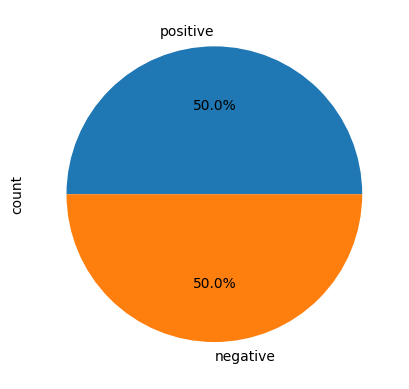

In [8]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%2.1f%%')

In [9]:
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df=df.drop_duplicates()

<Axes: ylabel='count'>

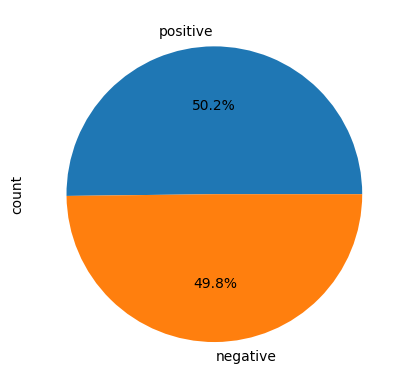

In [12]:




df['sentiment'].value_counts().plot(kind='pie', autopct='%2.1f%%')

In [13]:
df.shape

(49582, 2)

expanding short forms

In [14]:
import contractions

df['review'] = df['review'].apply(contractions.fix)

Lowercassing

In [15]:
df['review']=df['review'].str.lower()

In [16]:
df['review'][5]

'probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble because, but it is not preachy or boring. it just never gets old, despite my having seen it some 15 or more times in the last 25 years. paul lukas\' performance brings tears to my eyes, and bette davis, in one of her very few truly sympathetic roles, is a delight. the kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. and the mother\'s slow awakening to what is happening in the world and under her own roof is believable and startling. if i had a dozen thumbs, they would all be "up" for this movie.'

In [17]:
df['review']=df['review'].str.replace(r'<.*?>','',regex=True)

In [18]:
df['review'][5]

'probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble because, but it is not preachy or boring. it just never gets old, despite my having seen it some 15 or more times in the last 25 years. paul lukas\' performance brings tears to my eyes, and bette davis, in one of her very few truly sympathetic roles, is a delight. the kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. and the mother\'s slow awakening to what is happening in the world and under her own roof is believable and startling. if i had a dozen thumbs, they would all be "up" for this movie.'

In [19]:
df['review']=df['review'].str.replace('/','')

In [20]:
df['review'][5]

'probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble because, but it is not preachy or boring. it just never gets old, despite my having seen it some 15 or more times in the last 25 years. paul lukas\' performance brings tears to my eyes, and bette davis, in one of her very few truly sympathetic roles, is a delight. the kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. and the mother\'s slow awakening to what is happening in the world and under her own roof is believable and startling. if i had a dozen thumbs, they would all be "up" for this movie.'

Removing Punctuation

In [21]:
import string
translate=str.maketrans('','',string.punctuation)
df['review']=df['review'].str.translate(translate)

In [22]:
df['review'][5]

'probably my alltime favorite movie a story of selflessness sacrifice and dedication to a noble because but it is not preachy or boring it just never gets old despite my having seen it some 15 or more times in the last 25 years paul lukas performance brings tears to my eyes and bette davis in one of her very few truly sympathetic roles is a delight the kids are as grandma says more like dressedup midgets than children but that only makes them more fun to watch and the mothers slow awakening to what is happening in the world and under her own roof is believable and startling if i had a dozen thumbs they would all be up for this movie'

In [58]:
df.to_csv('cleaned_data.csv', index=False)

Spelling Correction

In [23]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there is a family where a little boy...,negative
4,petter matteis love in the time of money is a ...,positive


In [24]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

stop_words.remove('not')
stop_words.remove('no')
stop_words.remove('nor')
def remove_stop_words(text):
    new_text = []

    for word in text.split():
        if word not in stop_words:
            new_text.append(word)

    return " ".join(new_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
df['review']=df['review'].apply(remove_stop_words)

In [26]:
df['review'][5]

'probably alltime favorite movie story selflessness sacrifice dedication noble not preachy boring never gets old despite seen 15 times last 25 years paul lukas performance brings tears eyes bette davis one truly sympathetic roles delight kids grandma says like dressedup midgets children makes fun watch mothers slow awakening happening world roof believable startling dozen thumbs would movie'

Removing emoji if any

In [27]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.9 MB/s eta 0:00:00


In [28]:
import emoji
df['review']=df['review'].apply(lambda x: emoji.replace_emoji(x,replace=''))

Tokenization

In [29]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')
df['review']=df['review'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [30]:
df['review'][5]

['probably',
 'alltime',
 'favorite',
 'movie',
 'story',
 'selflessness',
 'sacrifice',
 'dedication',
 'noble',
 'not',
 'preachy',
 'boring',
 'never',
 'gets',
 'old',
 'despite',
 'seen',
 '15',
 'times',
 'last',
 '25',
 'years',
 'paul',
 'lukas',
 'performance',
 'brings',
 'tears',
 'eyes',
 'bette',
 'davis',
 'one',
 'truly',
 'sympathetic',
 'roles',
 'delight',
 'kids',
 'grandma',
 'says',
 'like',
 'dressedup',
 'midgets',
 'children',
 'makes',
 'fun',
 'watch',
 'mothers',
 'slow',
 'awakening',
 'happening',
 'world',
 'roof',
 'believable',
 'startling',
 'dozen',
 'thumbs',
 'would',
 'movie']

In [31]:
df['review'][5]

['probably',
 'alltime',
 'favorite',
 'movie',
 'story',
 'selflessness',
 'sacrifice',
 'dedication',
 'noble',
 'not',
 'preachy',
 'boring',
 'never',
 'gets',
 'old',
 'despite',
 'seen',
 '15',
 'times',
 'last',
 '25',
 'years',
 'paul',
 'lukas',
 'performance',
 'brings',
 'tears',
 'eyes',
 'bette',
 'davis',
 'one',
 'truly',
 'sympathetic',
 'roles',
 'delight',
 'kids',
 'grandma',
 'says',
 'like',
 'dressedup',
 'midgets',
 'children',
 'makes',
 'fun',
 'watch',
 'mothers',
 'slow',
 'awakening',
 'happening',
 'world',
 'roof',
 'believable',
 'startling',
 'dozen',
 'thumbs',
 'would',
 'movie']

lematization

In [32]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [33]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [34]:
print(lemmatizer.lemmatize("running"))
print(lemmatizer.lemmatize("studies"))

running
study


In [35]:
def lemmatize_text(tokens):
    new_text = []

    for word in tokens:
        lemma_word = lemmatizer.lemmatize(word)
        new_text.append(lemma_word)

    return new_text

In [36]:
df['review'] = df['review'].apply(lemmatize_text)

In [37]:
df['review'][5]

['probably',
 'alltime',
 'favorite',
 'movie',
 'story',
 'selflessness',
 'sacrifice',
 'dedication',
 'noble',
 'not',
 'preachy',
 'boring',
 'never',
 'get',
 'old',
 'despite',
 'seen',
 '15',
 'time',
 'last',
 '25',
 'year',
 'paul',
 'lukas',
 'performance',
 'brings',
 'tear',
 'eye',
 'bette',
 'davis',
 'one',
 'truly',
 'sympathetic',
 'role',
 'delight',
 'kid',
 'grandma',
 'say',
 'like',
 'dressedup',
 'midget',
 'child',
 'make',
 'fun',
 'watch',
 'mother',
 'slow',
 'awakening',
 'happening',
 'world',
 'roof',
 'believable',
 'startling',
 'dozen',
 'thumb',
 'would',
 'movie']

In [38]:
df.head()

,review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [39]:
df['review'] = df['review'].apply(lambda x: " ".join(x))

In [40]:
df.head()

,review,sentiment
0,one reviewer mentioned watching 1 oz episode h...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake think zombie ...,negative
4,petter matteis love time money visually stunni...,positive


In [41]:
df.to_csv("cleaned.csv")

In [42]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tft

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [44]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [45]:
X_test_tfidf = tfidf.transform(X_test)

In [46]:
print(X_train_tfidf.shape)

(39665, 180738)


In [47]:
print(tfidf.vocabulary_)

{'one': 114001, 'jehovah': 84793, 'witness': 176610, 'also': 8553, 'work': 177290, 'acute': 5525, 'care': 26573, 'medical': 100018, 'facility': 56006, 'year': 178992, 'seen': 140289, 'people': 119487, 'die': 43502, 'hemolytic': 73575, 'reaction': 129720, 'blood': 20520, 'transfusion': 163738, 'attended': 13524, 'numerous': 112097, 'conference': 34547, 'born': 22002, 'pathogen': 118712, 'several': 142014, 'patient': 118739, 'become': 17300, 'seriously': 141727, 'ill': 78983, 'induced': 80531, 'transfused': 163737, 'heard': 72876, 'told': 162218, 'refuse': 131081, '26': 2099, 'field': 58483, 'never': 109094, 'actually': 5483, 'happen': 71592, 'leaving': 91249, 'question': 128160, 'really': 129979, 'unreasonable': 168272, 'community': 33736, 'large': 90159, 'benefiting': 18273, 'battle': 16715, 'issue': 83206, 'moral': 104449, 'must': 107226, 'abstain': 4275, 'not': 111129, 'ambiguous': 8932, 'statement': 150746, 'thank': 158358, 'movie': 105337, 'allowing': 8118, 'comment': 33526, 'among

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [49]:
y_pred = model.predict(X_test_tfidf)

In [50]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8887768478370475


svm

In [51]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

pred = svm.predict(X_test_tfidf)

print(accuracy_score(y_test, pred))

0.8936170212765957


beg of words

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_train_bow=bow.fit_transform(X_train)
X_test_bow=bow.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression

model_bow = LogisticRegression(max_iter=1000)

model_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

In [57]:
pred_bow = model_bow.predict(X_test_bow)

print(accuracy_score(y_test, pred_bow))

0.8828274679842695


In [73]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=2000)

svm.fit(X_train_bow, y_train)

pred_bow_s = svm.predict(X_test_bow)

print(accuracy_score(y_test, pred_bow_s))

0.8675002520923667


word2vec

In [58]:
df['review']=df['review'].apply(word_tokenize)

In [60]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.0 MB/s eta 0:00:00


In [61]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df['review'],   # tokenized reviews
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [62]:
print(w2v_model.wv.most_similar('good'))

[('decent', 0.773905873298645), ('great', 0.703851044178009), ('alright', 0.6694880127906799), ('bad', 0.6640992164611816), ('okay', 0.6483240723609924), ('ok', 0.6475344896316528), ('nice', 0.6468716859817505), ('fine', 0.6460395455360413), ('cool', 0.6187924146652222), ('excellent', 0.5945274829864502)]


In [63]:
import numpy as np

def document_vector(tokens):

    word_vectors = []

    for word in tokens:
        if word in w2v_model.wv:
            word_vectors.append(w2v_model.wv[word])

    if len(word_vectors) == 0:
        return np.zeros(100)

    return np.mean(word_vectors, axis=0)

In [64]:
X = np.array(
    [document_vector(review)
     for review in df['review']]
)

In [65]:
print(X.shape)

(49582, 100)


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [68]:
pred = model.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, pred))

0.8607441766663305


In [70]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

print(accuracy_score(y_test, pred))

0.8603408288797015


In [75]:
from sklearn.svm import LinearSVC

# Re-create TF-IDF LinearSVC and its prediction
svm_tfidf = LinearSVC()
svm_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf_svc = svm_tfidf.predict(X_test_tfidf)

# Re-create Word2Vec LinearSVC and its prediction (svm from QB-CZD5Ct_oO was overwritten)
svm_w2v = LinearSVC()
svm_w2v.fit(X_train, y_train) # X_train here is Word2Vec X_train
pred_w2v_svc = svm_w2v.predict(X_test) # X_test here is Word2Vec X_test

# The 'model' variable is already the Logistic Regression trained on Word2Vec (from CniATVwItxtg)
pred_w2v_lr = model.predict(X_test)

results = pd.DataFrame({
    'Text Representation': [
        'TF-IDF', 'TF-IDF',
        'Bag of Words', 'Bag of Words',
        'Word2Vec', 'Word2Vec'
    ],
    'Model': [
        'Logistic Regression', 'LinearSVC',
        'Logistic Regression', 'LinearSVC',
        'Logistic Regression', 'LinearSVC'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred), # TF-IDF Logistic Regression
        accuracy_score(y_test, pred_tfidf_svc), # TF-IDF LinearSVC
        accuracy_score(y_test, pred_bow), # Bag of Words Logistic Regression
        accuracy_score(y_test, pred_bow_s), # Bag of Words LinearSVC
        accuracy_score(y_test, pred_w2v_lr), # Word2Vec Logistic Regression
        accuracy_score(y_test, pred_w2v_svc) # Word2Vec LinearSVC
    ]
})
display(results)

,Text Representation,Model,Accuracy
0,TF-IDF,Logistic Regression,0.888777
1,TF-IDF,LinearSVC,0.893617
2,Bag of Words,Logistic Regression,0.882827
3,Bag of Words,LinearSVC,0.867500
4,Word2Vec,Logistic Regression,0.860744
5,Word2Vec,LinearSVC,0.860341
